##Phase 1: Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
print("RDKit is working")

RDKit is working


In [2]:
path = r"C:\Users\Admin\Desktop\CS\ChemCompitiion\Lipophilicity.csv"

df = pd.read_csv(path)
print(df.head())

   CMPD_CHEMBLID   exp                                             smiles
0   CHEMBL596271  3.54            Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1  CHEMBL1951080 -1.18  COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2     CHEMBL1771  3.69             COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3   CHEMBL234951  3.37  OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4   CHEMBL565079  3.10  Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


##Phase 2: Exploratory Data Analysis (EDA)

2.1 Target Variable Analysis

In [3]:
df.shape

(4200, 3)

In [4]:
df.columns

Index(['CMPD_CHEMBLID', 'exp', 'smiles'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CMPD_CHEMBLID  4200 non-null   object 
 1   exp            4200 non-null   float64
 2   smiles         4200 non-null   object 
dtypes: float64(1), object(2)
memory usage: 98.6+ KB


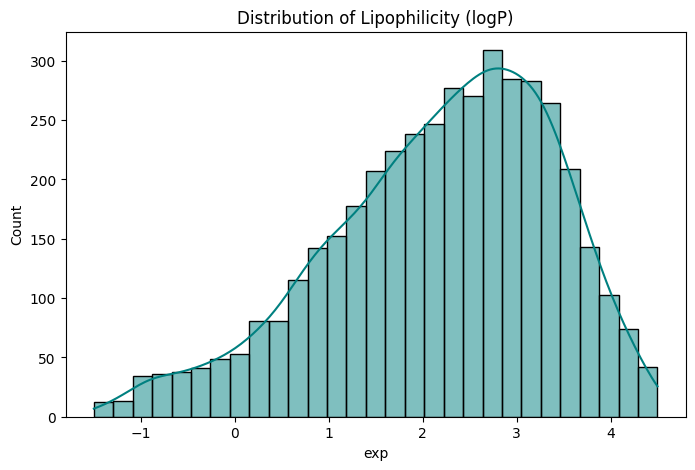

In [28]:
%matplotlib inline

plt.figure(figsize=(8, 5))
sns.histplot(df['exp'], kde=True, color='teal')
plt.title('Distribution of Lipophilicity (logP)')
plt.savefig('Distribution of Lipophilicity (logP)')
plt.show()

In [7]:
df.describe()

,exp
count,4200.000000
mean,2.186336
std,1.203004
min,-1.500000
25%,1.410000
50%,2.360000
75%,3.100000
max,4.500000


2.2 SMILES Validation

In [8]:
# 1. Create a function to check if a SMILES is valid
def is_valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

# 2. Count before cleaning
initial_count = len(df)

# 3. Apply the filter
# This creates a 'mask' of True/False values
valid_mask = df['smiles'].apply(is_valid_smiles)

# 4. Create the cleaned dataframe
df_cleaned = df[valid_mask].copy()

# 5. Report the results
final_count = len(df_cleaned)
dropped_count = initial_count - final_count

print(f"--- Data Sanitization Report ---")
print(f"Total molecules processed: {initial_count}")
print(f"Invalid molecules dropped: {dropped_count}")
print(f"Final dataset size:        {final_count}")

# Update your main df to the cleaned version
df = df_cleaned

--- Data Sanitization Report ---
Total molecules processed: 4200
Invalid molecules dropped: 0
Final dataset size:        4200


2.3 Molecular Descriptor Generation 

In [9]:
from rdkit.Chem import Descriptors, rdMolDescriptors

# --- 3. DESCRIPTOR CALCULATION ---
def get_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return pd.Series([None]*18)
    return pd.Series({
        'MW'         : Descriptors.MolWt(mol),
        'LogP_calc'  : Descriptors.MolLogP(mol),
        'TPSA'       : Descriptors.TPSA(mol),
        'HBD'        : Descriptors.NumHDonors(mol),
        'HBA'        : Descriptors.NumHAcceptors(mol),
        'RotBonds'   : Descriptors.NumRotatableBonds(mol),
        'AroRings'   : Descriptors.NumAromaticRings(mol),
        'RingCount'  : Descriptors.RingCount(mol),
        'fCSP3'      : Descriptors.FractionCSP3(mol),
        'LabuteASA'  : Descriptors.LabuteASA(mol),
        'BertzCT'    : Descriptors.BertzCT(mol),
        'Chi0v'      : Descriptors.Chi0v(mol),
        'Chi1v'      : Descriptors.Chi1v(mol),
        'Kappa1'     : Descriptors.Kappa1(mol),
        'Kappa2'     : Descriptors.Kappa2(mol),
        'PEOE_VSA1'  : Descriptors.PEOE_VSA1(mol),
        'SMR_VSA1'   : Descriptors.SMR_VSA1(mol),
        'SlogP_VSA1' : Descriptors.SlogP_VSA1(mol),
    })

# Apply to all SMILES
descriptors_df = df['smiles'].apply(get_descriptors)

# Validate SMILES — flag invalid ones
invalid = descriptors_df.isnull().all(axis=1).sum()
print(f"Invalid SMILES: {invalid}")

# Drop invalid rows
descriptors_df = descriptors_df.dropna()
y = df.loc[descriptors_df.index, 'exp'].reset_index(drop=True)
descriptors_df = descriptors_df.reset_index(drop=True)

print(f"Valid molecules: {len(descriptors_df)}")
print(f"Columns: {descriptors_df.columns.tolist()}")
print(f"Any duplicate columns: {descriptors_df.columns.duplicated().any()}")


Invalid SMILES: 0
Valid molecules: 4200
Columns: ['MW', 'LogP_calc', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'AroRings', 'RingCount', 'fCSP3', 'LabuteASA', 'BertzCT', 'Chi0v', 'Chi1v', 'Kappa1', 'Kappa2', 'PEOE_VSA1', 'SMR_VSA1', 'SlogP_VSA1']
Any duplicate columns: False


2.4 Descriptor Distribution Analysis

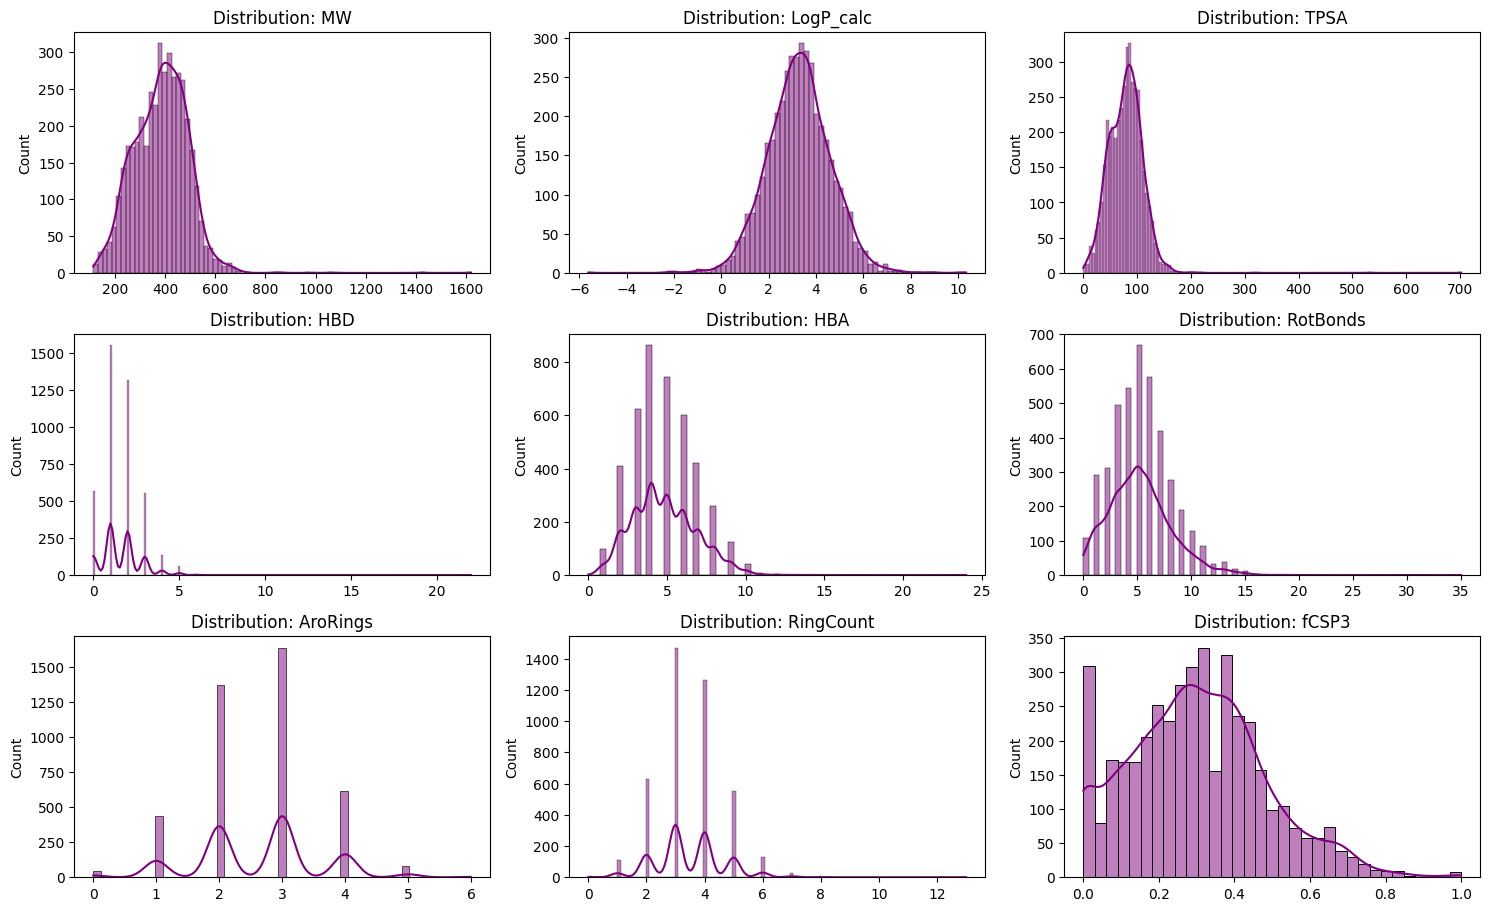

In [29]:
# 4.2 Descriptor distributions (original 10 only for EDA)
eda_features = ['MW', 'LogP_calc', 'TPSA', 'HBD', 'HBA',
                'RotBonds', 'AroRings', 'RingCount', 'HeavyAtoms', 'fCSP3'] \
               if 'HeavyAtoms' in descriptors_df.columns else \
               ['MW', 'LogP_calc', 'TPSA', 'HBD', 'HBA',
                'RotBonds', 'AroRings', 'RingCount', 'fCSP3']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(eda_features):
    plt.subplot(4, 3, i + 1)
    sns.histplot(descriptors_df[feature], kde=True, color='purple')
    plt.title(f'Distribution: {feature}')
    plt.xlabel('')
plt.tight_layout()
plt.savefig(f'Distribution: {feature}')
plt.show()

2.5 Correlation Analysis

In [11]:
# 4.3 Variance report
variance_report = descriptors_df.var()
print("--- Feature Variance Report ---")
print(variance_report)
low_variance = variance_report[variance_report < 0.01].index.tolist()
print(f"\nUseless features (near-zero variance): {low_variance}")

--- Feature Variance Report ---
MW             11450.162764
LogP_calc          1.749793
TPSA            1028.810559
HBD                1.350683
HBA                4.174320
RotBonds           8.451740
AroRings           0.946677
RingCount          1.305358
fCSP3              0.032650
LabuteASA       1902.415311
BertzCT       109216.796439
Chi0v             19.858007
Chi1v              8.121877
Kappa1            33.092460
Kappa2             7.677769
PEOE_VSA1         61.727776
SMR_VSA1          79.201243
SlogP_VSA1        42.528025
dtype: float64

Useless features (near-zero variance): []


2.6 Outlier Detection

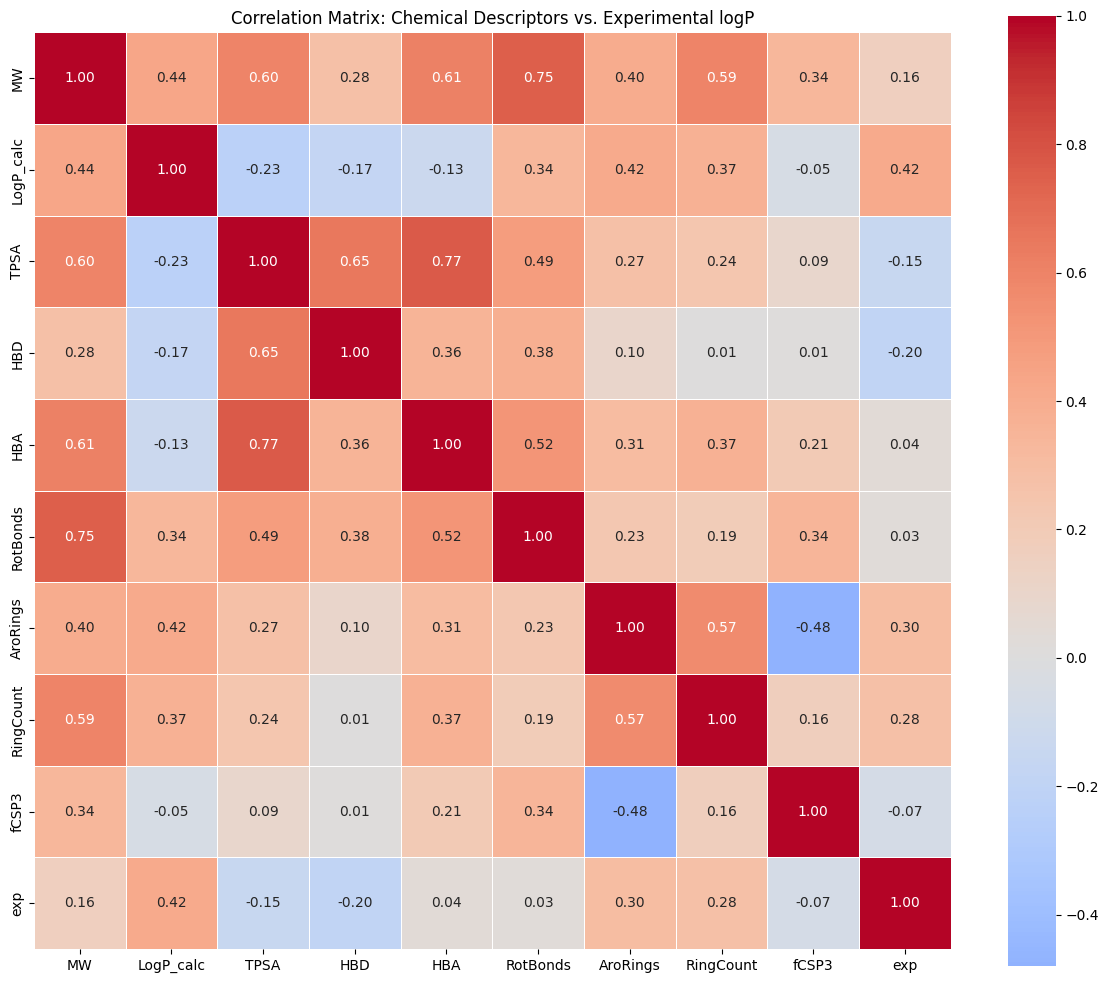

In [33]:
# 4.4 Correlation heatmap
corr_df = descriptors_df[['MW', 'LogP_calc', 'TPSA', 'HBD', 'HBA',
                           'RotBonds', 'AroRings', 'RingCount', 'fCSP3']].copy()
corr_df['exp'] = y

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    square=True, linewidths=0.5
)
plt.title('Correlation Matrix: Chemical Descriptors vs. Experimental logP')
plt.tight_layout()
plt.savefig('correlation_matrix_descriptors_vs_logP.png')
plt.show()

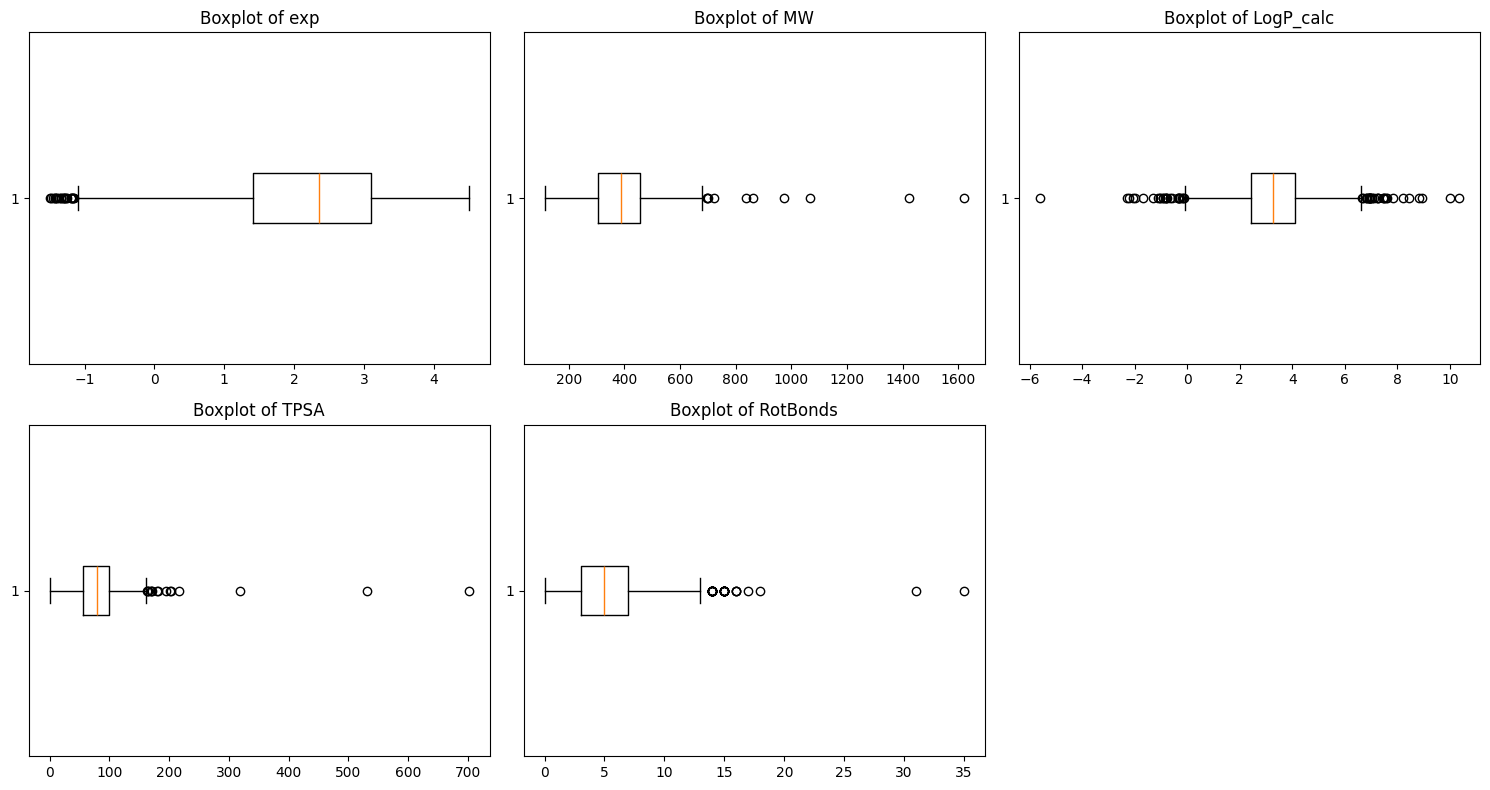

In [34]:
# 4.5 Boxplots for outlier detection
boxplot_features = ['exp', 'MW', 'LogP_calc', 'TPSA', 'RotBonds']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feature in enumerate(boxplot_features):
    data = y if feature == 'exp' else descriptors_df[feature]
    axes[i].boxplot(data, vert=False)
    axes[i].set_title(f'Boxplot of {feature}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('outlier_detection_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

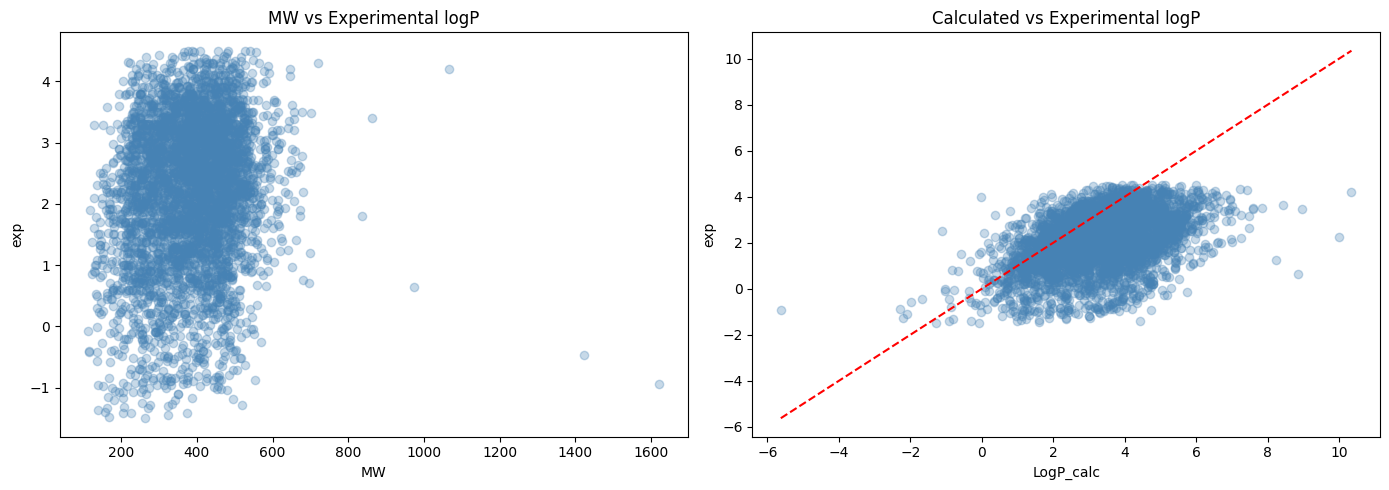

In [35]:
# 4.6 Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(descriptors_df['MW'], y, alpha=0.3, color='steelblue')
axes[0].set_xlabel('MW')
axes[0].set_ylabel('exp')
axes[0].set_title('MW vs Experimental logP')

axes[1].scatter(descriptors_df['LogP_calc'], y, alpha=0.3, color='steelblue')
axes[1].set_xlabel('LogP_calc')
axes[1].set_ylabel('exp')
axes[1].set_title('Calculated vs Experimental logP')

# Add diagonal reference line
lims = [min(descriptors_df['LogP_calc'].min(), y.min()),
        max(descriptors_df['LogP_calc'].max(), y.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1.5)
plt.tight_layout()
plt.savefig('scatter_plots_logP_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

Phase 3: Preprocessing

In [16]:
# --- 5. PREPROCESSING ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 5.1 Define final features (HeavyAtoms excluded — multicollinearity with MW r=0.98)
final_features = [
    'MW', 'LogP_calc', 'TPSA', 'HBD', 'HBA',
    'RotBonds', 'AroRings', 'RingCount', 'fCSP3',
    'LabuteASA', 'BertzCT', 'Chi0v', 'Chi1v',
    'Kappa1', 'Kappa2', 'PEOE_VSA1', 'SMR_VSA1', 'SlogP_VSA1'
]

X = descriptors_df[final_features].copy()

# 5.2 Fill any remaining NaNs
X = X.fillna(X.mean())

# 5.3 Verify no duplicates
assert not X.columns.duplicated().any(), "Duplicate columns detected"
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

# 5.4 Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5.5 Scale — fit on train only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5.6 Final verification
assert scaler.feature_names_in_.tolist() == final_features, "Feature mismatch"
print("Preprocessing complete. Scaler matches final_features: True")
print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

Feature matrix shape: (4200, 18)
Target shape: (4200,)
Preprocessing complete. Scaler matches final_features: True
Train: (3360, 18) | Test: (840, 18)


Phase 4: Modeling

In [18]:
# --- 6. MODEL TRAINING AND EVALUATION ---
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_error

# 6.1 Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression:")
print(f"  R²   = {r2_score(y_test, y_pred_lr):.3f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_lr):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.3f}\n")

Linear Regression:
  R²   = 0.263
  MAE  = 0.833
  RMSE = 1.043



In [20]:
# 6.2 Decision Tree
from sklearn.tree import DecisionTreeRegressor, plot_tree

dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree:")
print(f"  R²   = {r2_score(y_test, y_pred_dt):.3f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_dt):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_dt)):.3f}\n")

Decision Tree:
  R²   = 0.287
  MAE  = 0.810
  RMSE = 1.026



In [22]:
# 6.3 Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest:")
print(f"  R²   = {r2_score(y_test, y_pred_rf):.3f}")
print(f"  MAE  = {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.3f}")

Random Forest:
  R²   = 0.540
  MAE  = 0.612
  RMSE = 0.824


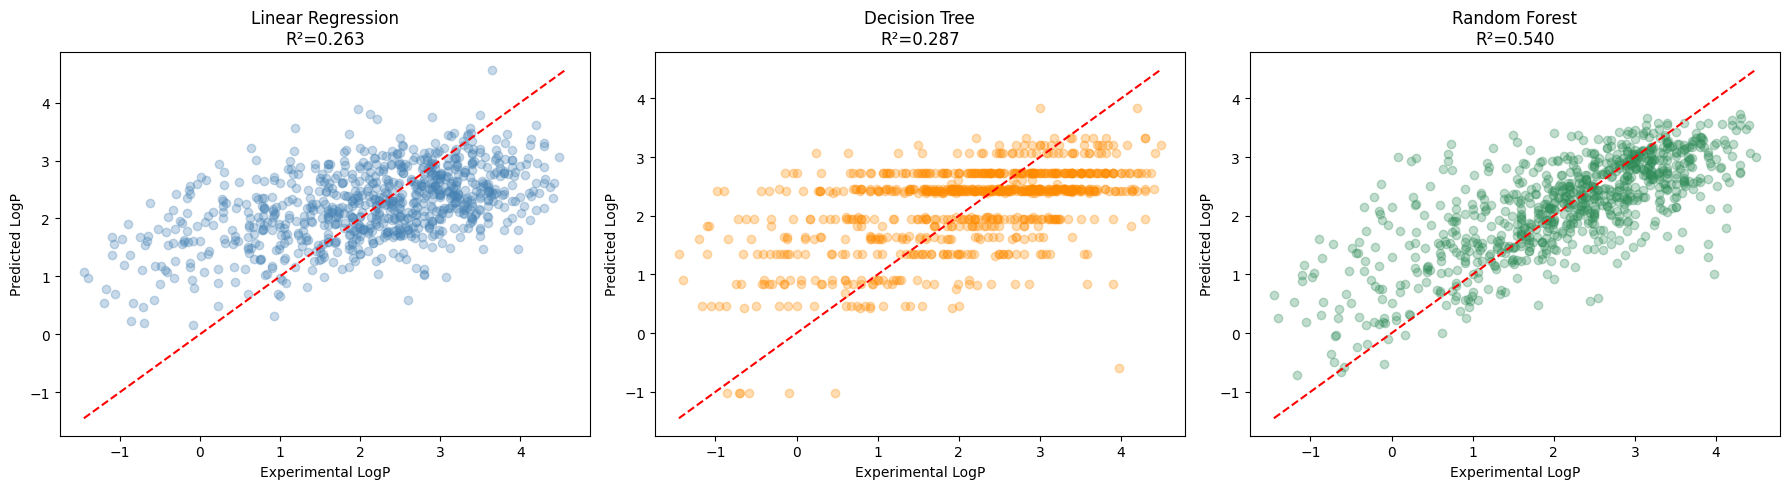

In [36]:
# --- 7. VISUALIZATION ---

# 7.1 Predicted vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    (y_pred_lr, 'Linear Regression', 'steelblue'),
    (y_pred_dt, 'Decision Tree',     'darkorange'),
    (y_pred_rf, 'Random Forest',     'seagreen'),
]
for ax, (y_pred, name, color) in zip(axes, models_info):
    ax.scatter(y_test, y_pred, alpha=0.3, color=color)
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Experimental LogP')
    ax.set_ylabel('Predicted LogP')
    ax.set_title(f'{name}\nR²={r2_score(y_test, y_pred):.3f}')
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

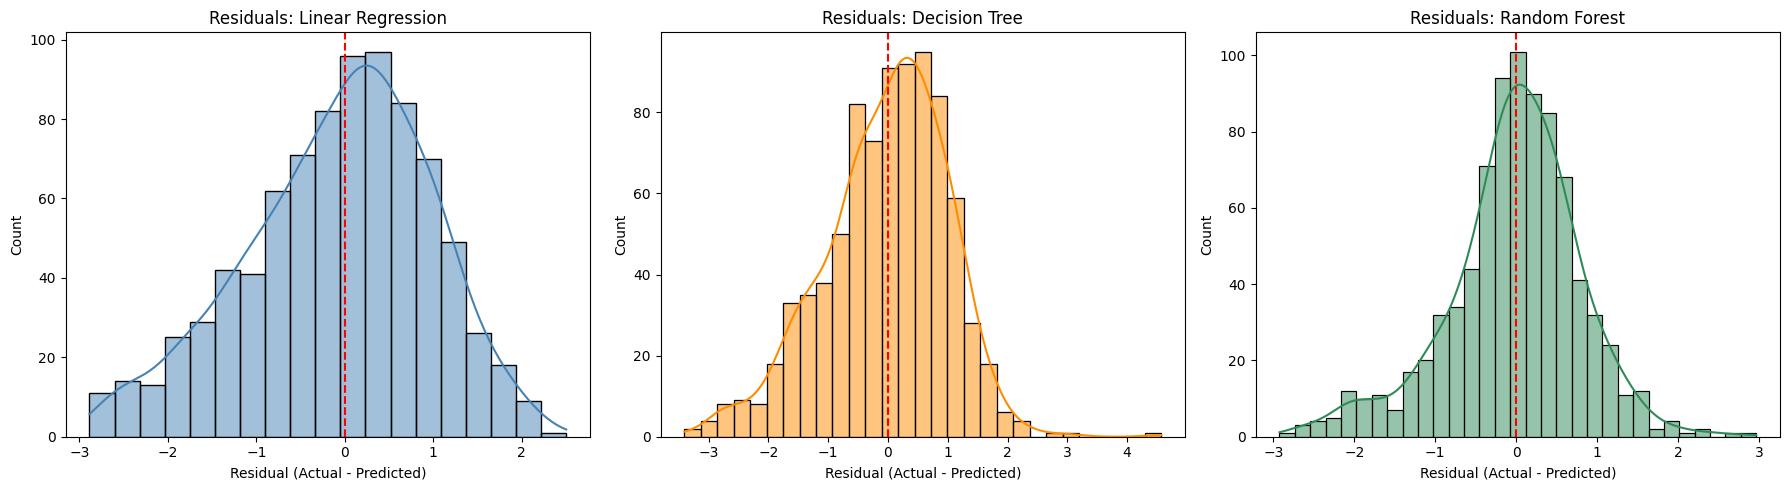

In [37]:
# 7.2 Residual distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (y_pred, name, color) in zip(axes, models_info):
    residuals = y_test - y_pred
    sns.histplot(residuals, kde=True, color=color, ax=ax)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_title(f'Residuals: {name}')
plt.tight_layout()
plt.savefig('model_residual_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

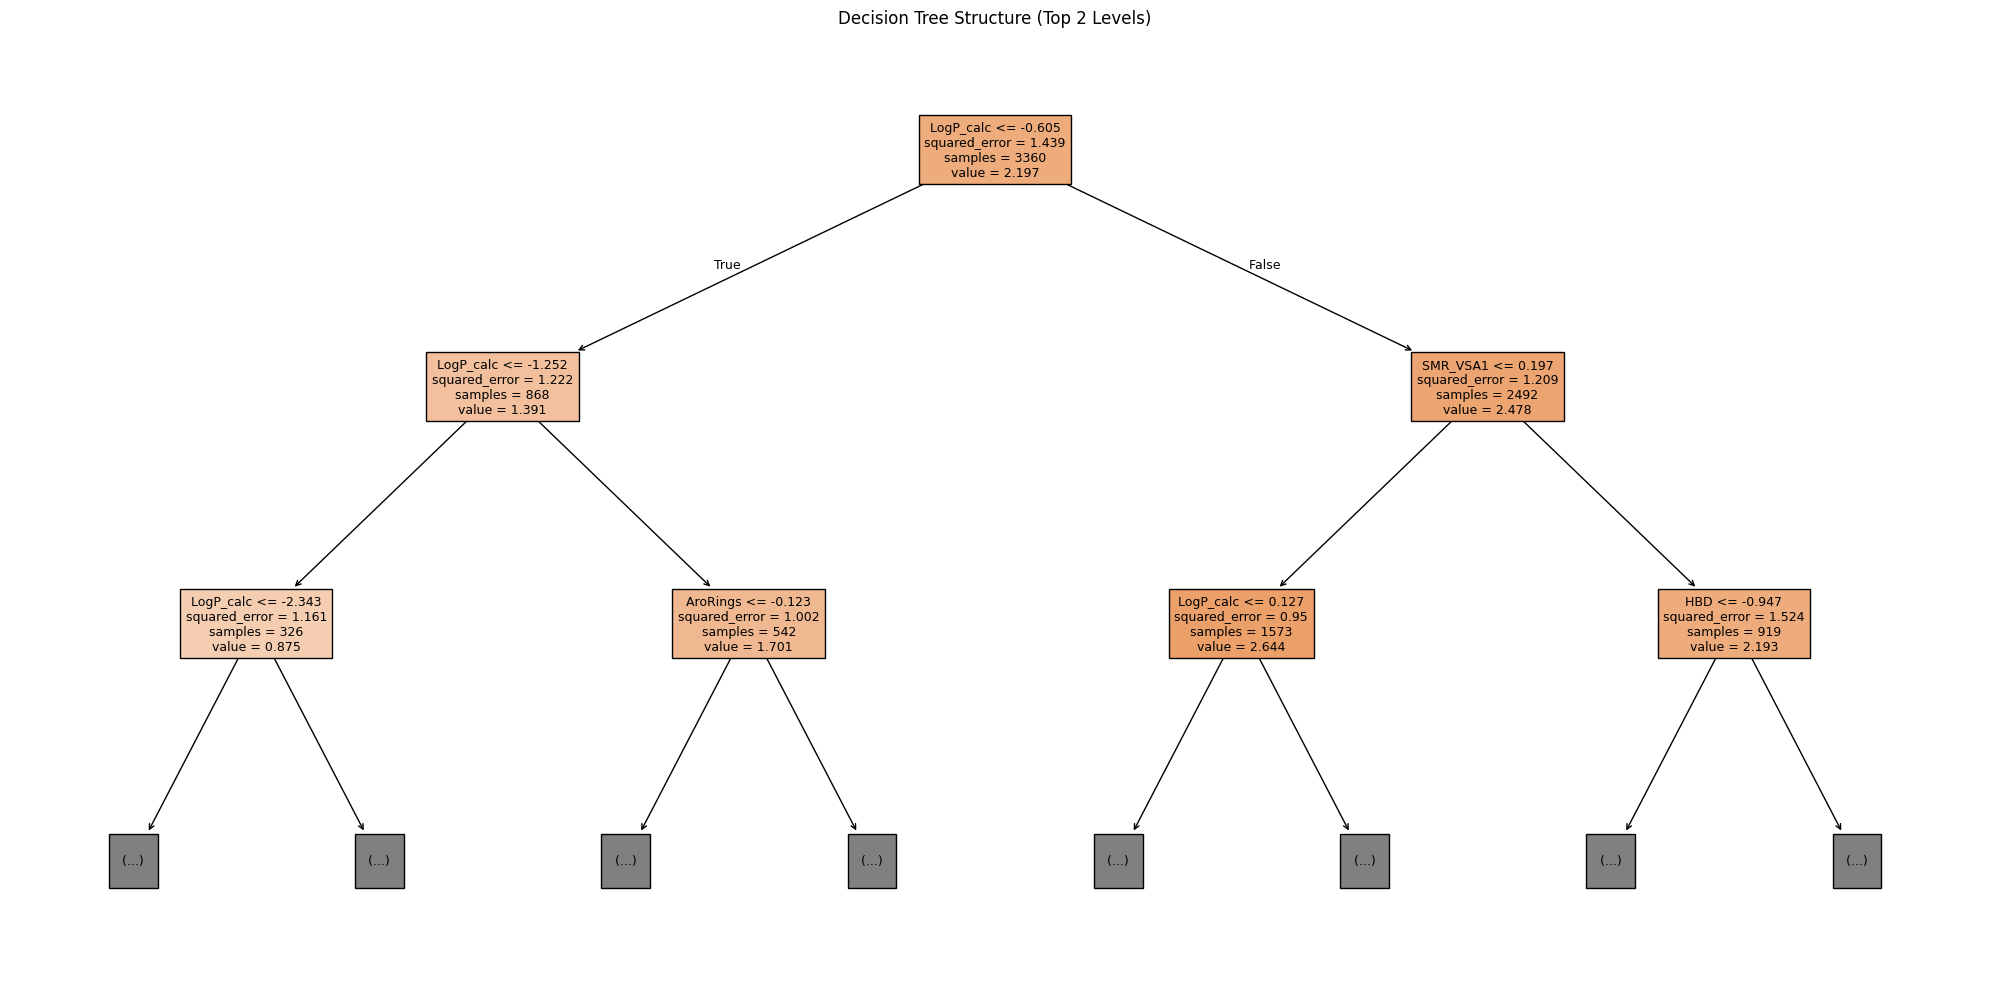

In [38]:
# 7.3 Decision tree visualization
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=final_features,
          filled=True, fontsize=9, max_depth=2)
plt.title('Decision Tree Structure (Top 2 Levels)')
plt.tight_layout()
plt.savefig('Decision Tree Structure (Top 2 Levels)')
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_17940\1686827674.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


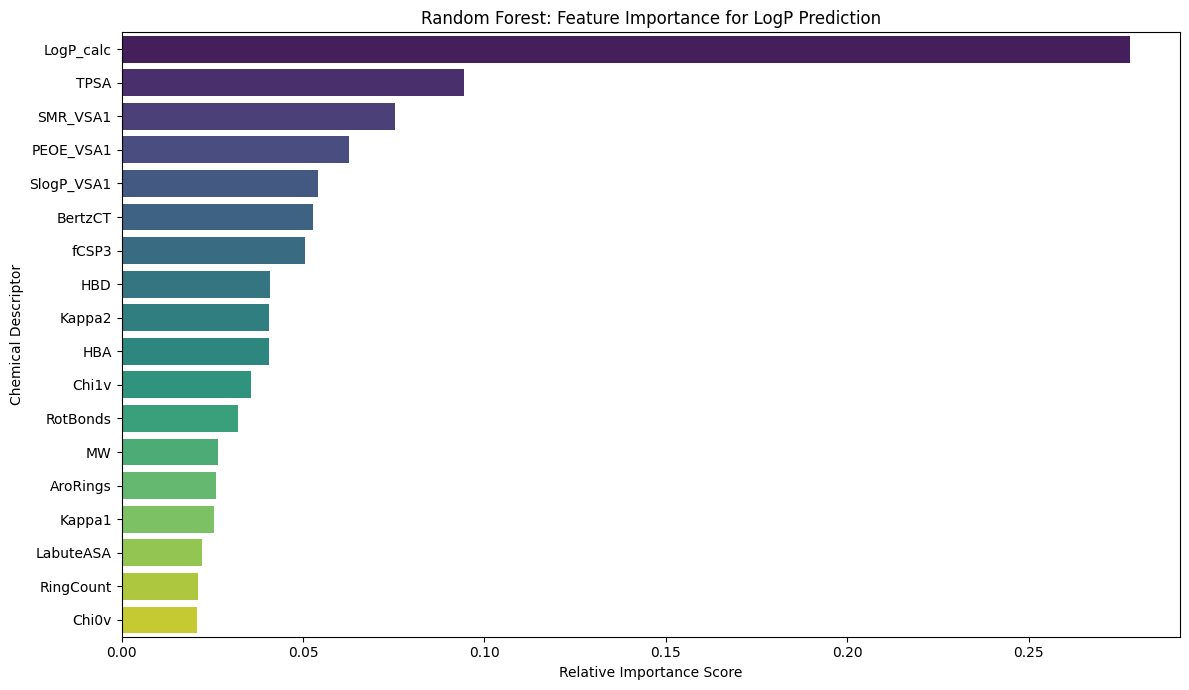

In [39]:
# 7.4 Random Forest feature importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 7))
sns.barplot(
    x=importances[indices],
    y=[final_features[i] for i in indices],
    palette='viridis'
)
plt.title('Random Forest: Feature Importance for LogP Prediction')
plt.xlabel('Relative Importance Score')
plt.ylabel('Chemical Descriptor')
plt.tight_layout()
plt.savefig('Random Forest: Feature Importance for LogP Prediction.png')
plt.show()

In [27]:
# --- 8. PREDICTION FUNCTION ---
def predict_lipophilicity(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Invalid SMILES string."

    features = {
        'MW'         : Descriptors.MolWt(mol),
        'LogP_calc'  : Descriptors.MolLogP(mol),
        'TPSA'       : Descriptors.TPSA(mol),
        'HBD'        : Descriptors.NumHDonors(mol),
        'HBA'        : Descriptors.NumHAcceptors(mol),
        'RotBonds'   : Descriptors.NumRotatableBonds(mol),
        'AroRings'   : Descriptors.NumAromaticRings(mol),
        'RingCount'  : Descriptors.RingCount(mol),
        'fCSP3'      : Descriptors.FractionCSP3(mol),
        'LabuteASA'  : Descriptors.LabuteASA(mol),
        'BertzCT'    : Descriptors.BertzCT(mol),
        'Chi0v'      : Descriptors.Chi0v(mol),
        'Chi1v'      : Descriptors.Chi1v(mol),
        'Kappa1'     : Descriptors.Kappa1(mol),
        'Kappa2'     : Descriptors.Kappa2(mol),
        'PEOE_VSA1'  : Descriptors.PEOE_VSA1(mol),
        'SMR_VSA1'   : Descriptors.SMR_VSA1(mol),
        'SlogP_VSA1' : Descriptors.SlogP_VSA1(mol),
    }

    features_df = pd.DataFrame([features])[final_features]
    features_scaled = scaler.transform(features_df)
    prediction = rf_model.predict(features_scaled)
    return round(prediction[0], 3)


# --- 9. INTERACTIVE PREDICTOR ---
print("--- Molecular Lipophilicity Predictor ---")
user_input = input("Enter a SMILES string: ")
result = predict_lipophilicity(user_input)

if isinstance(result, str):
    print(f"Error: {result}")
else:
    print(f"\nSMILES: {user_input}")
    print(f"Predicted LogP: {result}")
    if result > 3:
        print("Insight: Highly lipophilic (hydrophobic).")
    elif result < 1:
        print("Insight: Highly hydrophilic (water-soluble).")
    else:
        print("Insight: Balanced drug-like lipophilicity.")

--- Molecular Lipophilicity Predictor ---


Enter a SMILES string:  CC(C)Cc1ccc(cc1)C(C)C(=O)O



SMILES: CC(C)Cc1ccc(cc1)C(C)C(=O)O
Predicted LogP: 2.035
Insight: Balanced drug-like lipophilicity.


In [41]:
print(descriptors_df.head())

        MW  LogP_calc    TPSA  HBD  HBA  RotBonds  AroRings  RingCount  \
0  340.858     3.5489   24.30  0.0  3.0       3.0       3.0        4.0   
1  494.591     2.9901  122.24  2.0  7.0       9.0       2.0        3.0   
2  321.829     3.6739   29.54  0.0  4.0       3.0       2.0        3.0   
3  419.890     1.9237  105.66  4.0  5.0       5.0       3.0        4.0   
4  381.480     2.0069   99.81  2.0  4.0       6.0       2.0        2.0   

      fCSP3   LabuteASA      BertzCT      Chi0v      Chi1v     Kappa1  \
0  0.315789  146.815697   832.199002  14.577084   8.715604  15.485518   
1  0.363636  196.670037  1151.428500  20.163286  12.758861  24.717123   
2  0.312500  132.650849   655.231463  13.285121   8.077393  14.571987   
3  0.263158  169.092923  1015.409752  16.256898   9.925507  18.949471   
4  0.428571  165.290384   902.250256  17.036453   9.171258  21.163377   

      Kappa2  PEOE_VSA1   SMR_VSA1  SlogP_VSA1  
0   6.457627   9.467009   0.000000    4.899910  
1  10.344648  19.8

In [42]:
descriptors_df.to_csv('your_filename.csv', index=False)